In [ ]:
# Paramdeep Choudhary
# cu24250162
# Labsheet 07

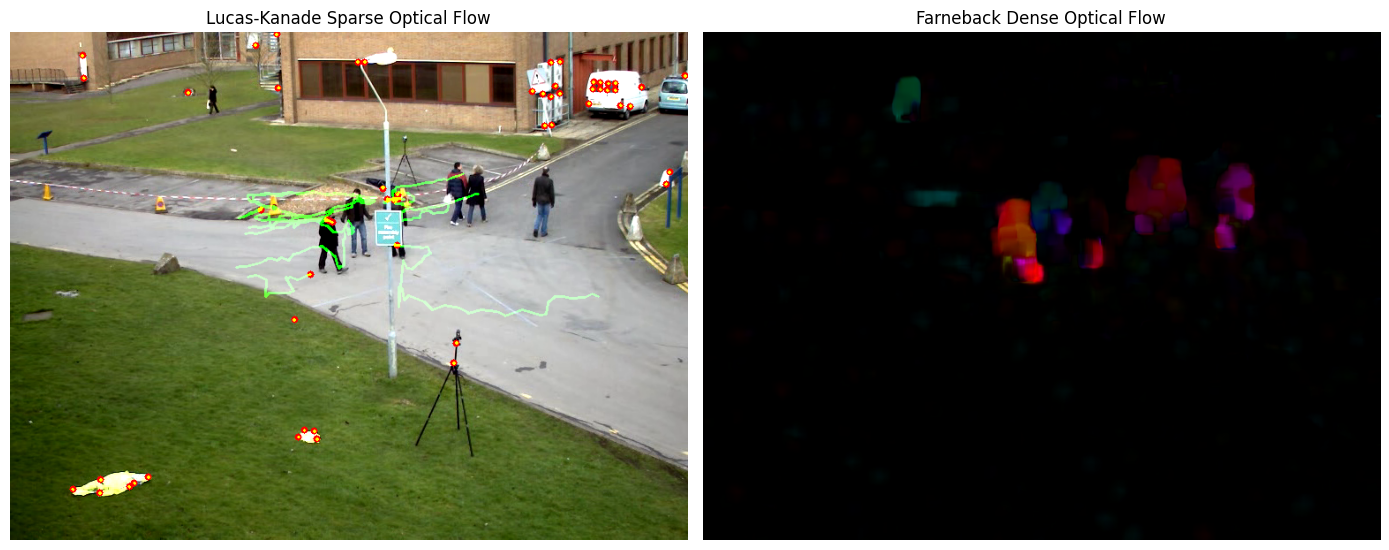

Optical Flow Experiment Completed Successfully!
Total frames processed: 100


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

video_url = "https://github.com/opencv/opencv/raw/4.x/samples/data/vtest.avi"
video_path = "vtest.avi"

!wget -q {video_url} -O {video_path}

cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read video.")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    feature_params = dict(
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    mask_lk = np.zeros_like(old_frame)

    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Lucas-Kanade Sparse Optical Flow
        if p0 is not None:
            p1, st, err = cv2.calcOpticalFlowPyrLK(
                old_gray,
                frame_gray,
                p0,
                None,
                **lk_params
            )

            if p1 is not None:
                good_new = p1[st == 1]
                good_old = p0[st == 1]

                for new, old in zip(good_new, good_old):
                    x_new, y_new = new.ravel()
                    x_old, y_old = old.ravel()

                    mask_lk = cv2.line(
                        mask_lk,
                        (int(x_new), int(y_new)),
                        (int(x_old), int(y_old)),
                        (0, 255, 0),
                        2
                    )

                    frame = cv2.circle(
                        frame,
                        (int(x_new), int(y_new)),
                        4,
                        (0, 0, 255),
                        -1
                    )

                lk_output = cv2.add(frame, mask_lk)

                p0 = good_new.reshape(-1, 1, 2)

                if len(p0) < 10:
                    p0 = cv2.goodFeaturesToTrack(
                        frame_gray,
                        mask=None,
                        **feature_params
                    )
            else:
                lk_output = frame.copy()
                p0 = cv2.goodFeaturesToTrack(
                    frame_gray,
                    mask=None,
                    **feature_params
                )
        else:
            lk_output = frame.copy()
            p0 = cv2.goodFeaturesToTrack(
                frame_gray,
                mask=None,
                **feature_params
            )

        # Farneback Dense Optical Flow
        flow = cv2.calcOpticalFlowFarneback(
            old_gray,
            frame_gray,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        magnitude, angle = cv2.cartToPolar(
            flow[..., 0],
            flow[..., 1]
        )

        hsv = np.zeros_like(frame)
        hsv[..., 1] = 255

        hsv[..., 0] = angle * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        farneback_output = cv2.cvtColor(
            hsv,
            cv2.COLOR_HSV2BGR
        )

        # Display both optical flow methods
        lk_rgb = cv2.cvtColor(lk_output, cv2.COLOR_BGR2RGB)
        dense_rgb = cv2.cvtColor(
            farneback_output,
            cv2.COLOR_BGR2RGB
        )

        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].imshow(lk_rgb)
        axes[0].set_title("Lucas-Kanade Sparse Optical Flow")
        axes[0].axis("off")

        axes[1].imshow(dense_rgb)
        axes[1].set_title("Farneback Dense Optical Flow")
        axes[1].axis("off")

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        old_gray = frame_gray.copy()

        if frame_count >= 100:
            break

    cap.release()

    print("Optical Flow Experiment Completed Successfully!")
    print("Total frames processed:", frame_count)


In [ ]:
# Experiment No. 7
# Experiment Name: Motion Estimation using Optical Flow Algorithms in Video Sequences

# Q1. What is Optical Flow? How is it used in computer vision?
# Optical Flow is the apparent motion of objects, surfaces, or the camera
# between consecutive frames of a video.
# It is used to estimate the direction and speed of motion.
# It is useful in object tracking, surveillance, robotics, autonomous driving,
# gesture recognition, and sports analysis.

# Q2. Explain the working principle of the Lucas-Kanade Optical Flow algorithm.
# Lucas-Kanade is a Sparse Optical Flow algorithm.
# It tracks selected feature points between consecutive video frames.
# It assumes that pixels within a small neighborhood have similar motion.
# Image gradients are used to estimate the horizontal and vertical motion
# of the selected feature points.

# Q3. What is Dense Optical Flow? How does it differ from Sparse Optical Flow?
# Dense Optical Flow estimates motion for almost every pixel in an image.
# Farneback Optical Flow is an example of Dense Optical Flow.
# Sparse Optical Flow estimates motion only for selected feature points.
# Lucas-Kanade is commonly used for Sparse Optical Flow.
# Dense Optical Flow provides more complete motion information but requires
# more computational resources.

# Q4. Compare the Lucas-Kanade and Farneback optical flow algorithms.
# Lucas-Kanade is a Sparse Optical Flow method that tracks selected feature points.
# It is computationally efficient and suitable for feature tracking.
# Farneback is a Dense Optical Flow method that estimates motion across the image.
# It provides more complete motion information but requires more computation.
# Lucas-Kanade is suitable for object tracking, while Farneback is useful
# when motion information across the whole image is required.

# Q5. What assumptions are made while computing optical flow?
# The main assumptions are:
# 1. Brightness or intensity remains approximately constant.
# 2. Motion between consecutive frames is relatively small.
# 3. Neighboring pixels have similar motion.
# 4. The object surface is locally smooth.
# These assumptions help estimate the motion between consecutive frames.

# Q6. What factors can affect the accuracy of optical flow estimation?
# The accuracy can be affected by:
# 1. Fast object movement.
# 2. Changes in lighting conditions.
# 3. Motion blur.
# 4. Camera movement.
# 5. Object occlusion.
# 6. Low image resolution.
# 7. Textureless regions.
# 8. Noise in the video.
# 9. Large motion between consecutive frames.

# Q7. Mention five real-world applications of optical flow in computer vision.
# 1. Autonomous driving.
# 2. Video surveillance.
# 3. Object tracking.
# 4. Sports analysis.
# 5. Gesture and action recognition.

# Q8. Why are grayscale images generally used for optical flow computation?
# Grayscale images contain intensity information without requiring three
# separate color channels.
# Optical flow mainly uses intensity changes and image gradients.
# Converting images to grayscale reduces computational complexity and memory usage.
# It also simplifies gradient calculations.

# Q9. What are the limitations of optical flow algorithms in real-world environments?
# Common limitations include:
# 1. Sensitivity to lighting changes.
# 2. Difficulty with very fast motion.
# 3. Problems caused by object occlusion.
# 4. Motion blur can reduce accuracy.
# 5. Textureless regions are difficult to track.
# 6. Camera movement can affect motion estimation.
# 7. Dense optical flow can require significant computational resources.

# Q10. How does optical flow contribute to autonomous driving,
# video surveillance, and action recognition?
# In autonomous driving, optical flow helps estimate the movement of vehicles,
# pedestrians, and other objects.
# In video surveillance, it helps detect moving objects and analyze motion.
# In action recognition, motion patterns can be used to identify activities
# such as walking, running, or waving.
# Therefore, optical flow provides important motion information for
# understanding dynamic scenes.

# Conclusion:
# Lucas-Kanade Sparse Optical Flow and Farneback Dense Optical Flow were
# successfully implemented using Python and OpenCV.
# Lucas-Kanade tracks selected feature points, while Farneback estimates
# motion across the image.
# Optical flow is an important technique for motion estimation and
# dynamic scene analysis in computer vision.
